# iNaturalist Data by Trail

Change `TRAIL_NAME` in the first code cell, then run all cells.

This notebook imports reusable processing functions from `src/inaturalist.py`.
It displays recent and historical observations, including a static map of the trail and its one-mile buffer, without saving changing results.

In [37]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import HTML, display


# Works when the notebook is opened from the repository root
# or from the notebooks folder.
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src" / "inaturalist.py").exists():
    raise FileNotFoundError(
        "Could not find src/inaturalist.py. "
        "Place this notebook inside the project repository."
    )

sys.path.insert(0, str(PROJECT_ROOT))

from src.inaturalist import (
    MILES_TO_METERS,
    create_trail_buffer,
    fetch_recent_observations,
    filter_to_buffer,
    get_top_species,
    load_historical_observations,
    load_trails,
    summarize_species,
)


TRAIL_NAME = "Mackinac | North Country Trail"
BUFFER_MILES = 2.0

MAX_ACCURACY_METERS = BUFFER_MILES * MILES_TO_METERS

TRAILS_PATH = (
    PROJECT_ROOT
    / "data/processed/dnr_up_hiking_trails_grouped.parquet"
)

HISTORICAL_PATH = (
    PROJECT_ROOT
    / "data/raw/inaturalist_up_fall_observations_2015_2026.csv"
)

## Load data and select the trail

In [38]:
trails = load_trails(TRAILS_PATH)

available_trails = sorted(
    trails["TrailGroupName"].dropna().unique()
)

if TRAIL_NAME not in available_trails:
    raise ValueError(
        f"Trail not found: {TRAIL_NAME}\n"
        "Choose a value from available_trails."
    )

historical = load_historical_observations(
    HISTORICAL_PATH,
    max_accuracy_meters=MAX_ACCURACY_METERS,
)

selected_trail, trail_buffer = create_trail_buffer(
    trails,
    TRAIL_NAME,
    buffer_miles=BUFFER_MILES,
)

print(f"Selected trail: {TRAIL_NAME}")
print(f"Available trails: {len(available_trails):,}")
print(
    f"Search area: {BUFFER_MILES:g}-mile buffer "
    "around the trail"
)

Selected trail: Mackinac | North Country Trail
Available trails: 159
Search area: 2-mile buffer around the trail


## Prepare recent and historical summaries

In [39]:
historical_near_trail = filter_to_buffer(
    historical,
    trail_buffer,
)

historical_summary = summarize_species(
    historical_near_trail
)

historical_tables = get_top_species(
    historical_summary,
    top_n=5,
)


try:
    recent, recent_metadata = fetch_recent_observations(
        trail_buffer,
        days=14,
        max_accuracy_meters=MAX_ACCURACY_METERS
    )

    recent_near_trail = filter_to_buffer(
        recent,
        trail_buffer,
    )

    recent_summary = summarize_species(
        recent_near_trail
    )

except requests.RequestException as error:
    print(f"Recent iNaturalist request failed: {error}")

    recent_metadata = None
    recent_near_trail = pd.DataFrame()
    recent_summary = summarize_species(pd.DataFrame())


recent_tables = get_top_species(
    recent_summary,
    top_n=5,
)

print(
    "Recent observations inside buffer: "
    f"{len(recent_near_trail):,}"
)
print(
    "Historical observations inside buffer: "
    f"{len(historical_near_trail):,}"
)

Recent observations inside buffer: 36
Historical observations inside buffer: 805


## Map the trail, buffer, and observations

The shaded polygon is the one-mile search area. The thick line is the selected
trail. Historical observations use `x` markers, and recent observations use
circle markers.

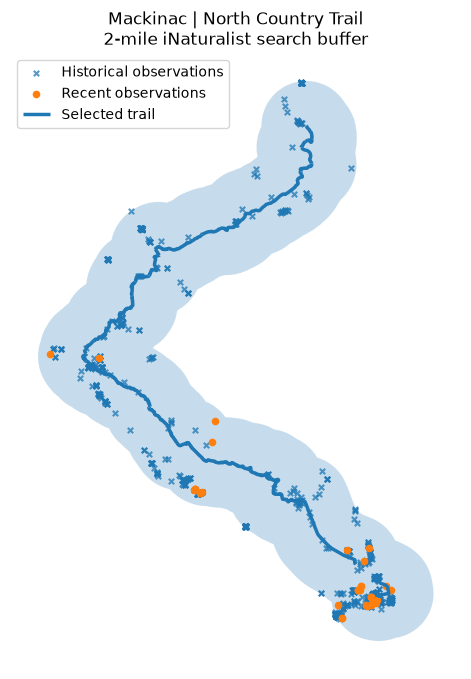

In [40]:
trail_projected = selected_trail.to_crs(trail_buffer.crs)

fig, ax = plt.subplots(figsize=(10, 8))

# Draw the one-mile search area first.
trail_buffer.plot(
    ax=ax,
    alpha=0.25,
)

# Historical observations use x markers.
if not historical_near_trail.empty:
    historical_near_trail.plot(
        ax=ax,
        marker="x",
        markersize=15,
        alpha=0.75,
        label="Historical observations",
    )

# Recent observations use circle markers.
if (
    hasattr(recent_near_trail, "geometry")
    and not recent_near_trail.empty
):
    recent_near_trail.plot(
        ax=ax,
        marker="o",
        markersize=20,
        label="Recent observations",
    )

# Draw the trail last so it remains visible.
trail_projected.plot(
    ax=ax,
    linewidth=2.5,
    label="Selected trail",
)

min_x, min_y, max_x, max_y = trail_buffer.total_bounds
padding = max(max_x - min_x, max_y - min_y) * 0.05

ax.set_xlim(min_x - padding, max_x + padding)
ax.set_ylim(min_y - padding, max_y + padding)
ax.set_title(
    f"{TRAIL_NAME}\n"
    f"{BUFFER_MILES:g}-mile iNaturalist search buffer"
)
ax.set_axis_off()

# Only display the legend when observation layers are present.
if (
    not historical_near_trail.empty
    or (
        hasattr(recent_near_trail, "geometry")
        and not recent_near_trail.empty
    )
):
    ax.legend()

plt.show()

## Display top species

In [41]:
def thumbnail_html(url):
    """Create a small image for the result table."""
    if pd.isna(url) or not url:
        return "No image"

    return (
        f'<img src="{url}" width="75" height="75" '
        f'alt="Species observation">'
    )


def display_species_tables(tables, heading, subtitle):
    """Display one top-five table for each nature group."""
    display(HTML(f"<h2>{heading}</h2><p>{subtitle}</p>"))

    for group_name, table in tables.items():
        display(HTML(f"<h3>{group_name}</h3>"))

        if table.empty:
            print("No qualifying observations found.")
            continue

        result = table[
            [
                "thumbnail_url",
                "common_name",
                "scientific_name",
                "observation_count",
                "most_recent_observation",
            ]
        ].rename(
            columns={
                "thumbnail_url": "Thumbnail",
                "common_name": "Common name",
                "scientific_name": "Scientific name",
                "observation_count": "Observations",
                "most_recent_observation": "Most recent",
            }
        ).copy()

        result["Thumbnail"] = result[
            "Thumbnail"
        ].apply(thumbnail_html)

        result["Most recent"] = pd.to_datetime(
            result["Most recent"]
        ).dt.strftime("%Y-%m-%d")

        display(
            HTML(
                result.to_html(
                    index=False,
                    escape=False,
                )
            )
        )


if recent_metadata is None:
    recent_subtitle = "Live iNaturalist data unavailable."
else:
    recent_subtitle = (
        f"{recent_metadata['start_date']} through "
        f"{recent_metadata['end_date']} · "
        f"{len(recent_near_trail):,} observations"
    )

display_species_tables(
    recent_tables,
    "Recent observations",
    recent_subtitle,
)


historical_start_year = historical["observed_on"].dt.year.min()
historical_end_year = historical["observed_on"].dt.year.max()

display_species_tables(
    historical_tables,
    "Historical fall observations",
    (
        f"September–October, {historical_start_year}-{historical_end_year}· "
        f"{len(historical_near_trail):,} observations"
    ),
)

Thumbnail,Common name,Scientific name,Observations,Most recent
,Ring-billed Gull,Larus delawarensis,2,2026-08-02
,Double-crested Cormorant,Nannopterum auritum,1,2026-07-25
,Canada Goose,Branta canadensis,1,2026-07-23


No qualifying observations found.


Thumbnail,Common name,Scientific name,Observations,Most recent
,Mezereon,Daphne mezereum,2,2026-07-24
,red baneberry,Actaea rubra,1,2026-08-03
,Painted-cup paintbrush,Castilleja coccinea,1,2026-08-02
,Kalm's Lobelia,Lobelia kalmii,1,2026-08-02
,Mountain holly,Ilex mucronata,1,2026-08-01


No qualifying observations found.


Thumbnail,Common name,Scientific name,Observations,Most recent
,Smooth Greensnake,Opheodrys vernalis,1,2026-07-23


...

Thumbnail,Common name,Scientific name,Observations,Most recent
,American Red Squirrel,Tamiasciurus hudsonicus,2,2025-09-07
,American Mink,Neogale vison,2,2022-10-23
,Eastern Chipmunk,Tamias striatus,1,2025-09-02
,Red Fox,Vulpes vulpes,1,2021-09-11


Thumbnail,Common name,Scientific name,Observations,Most recent
,tall coreopsis,Coreopsis tripteris,10,2025-09-27
,lesser fringed gentian,Gentianopsis virgata,10,2025-09-12
,fen grass of Parnassus,Parnassia glauca,10,2025-09-12
,northern whitecedar,Thuja occidentalis,9,2025-09-10
,bittersweet nightshade,Solanum dulcamara,8,2024-10-05


Thumbnail,Common name,Scientific name,Observations,Most recent
,Hanging Fringe Lichen,Anaptychia crinalis,6,2025-10-14
,American Yellow Fly Agaric,Amanita muscaria,6,2023-09-18
,The Humpback,Cantharellula umbonata,3,2021-09-27
,Tree Lungwort,Lobaria pulmonaria,2,2025-10-12
,Late Oyster,Sarcomyxa serotina,2,2025-10-12


Thumbnail,Common name,Scientific name,Observations,Most recent
,Painted Turtle,Chrysemys picta,1,2024-09-09
,Common Snapping Turtle,Chelydra serpentina,1,2018-09-03
,Eastern Garter Snake,Thamnophis sirtalis,1,2018-09-03


Thumbnail,Common name,Scientific name,Observations,Most recent
,Common Eastern Bumble Bee,Bombus impatiens,5,2025-09-13
,Common Green Darner,Anax junius,5,2024-09-01
,Soybean Looper Moth,Chrysodeixis includens,3,2025-09-18
,Maple Spanworm Moth,Ennomos magnaria,3,2025-09-18
,Monarch,Danaus plexippus,3,2024-09-21
